In [15]:
import pandas as pd 
data = pd.read_excel('data/Concrete_Data.xls')
data.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [19]:
data.describe()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


In [23]:
X = data.drop('Concrete compressive strength(MPa, megapascals) ', axis=1)
y = data['Concrete compressive strength(MPa, megapascals) ']

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [28]:
y_pred = model.predict(X_test)

In [30]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("R2 Score:", r2_score(y_test, y_pred))

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("RMSE:", rmse)

R2 Score: 0.6275416055429021
RMSE: 9.796707832398447


In [31]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred_rf))

R2 Score: 0.879131700419671


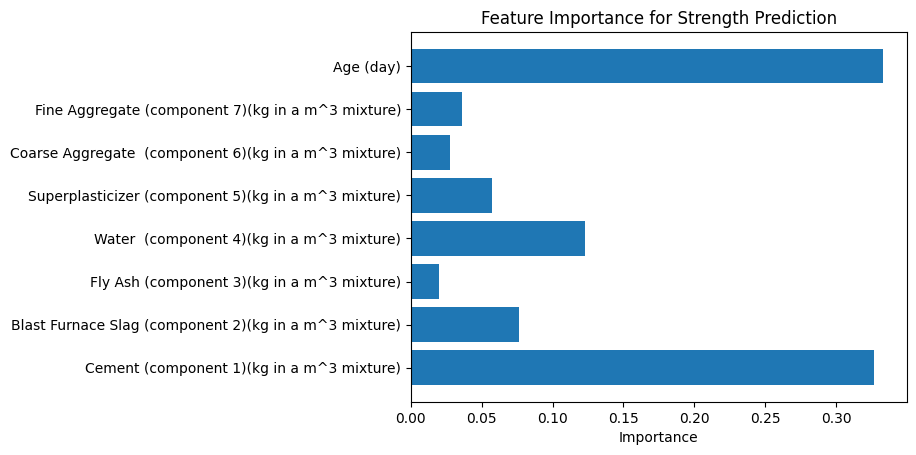

In [32]:
import matplotlib.pyplot as plt 
import pandas as pd 

importance = rf.feature_importances_
features = X.columns

plt.barh(features, importance)
plt.xlabel("Importance")
plt.title("Feature Importance for Strength Prediction")
plt.show()

In [33]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
    --------------------------------------- 2.4/101.7 MB 14.9 MB/s eta 0:00:07
   - -------------------------------------- 3.4/101.7 MB 8.8 MB/s eta 0:00:12
   - -------------------------------------- 4.5/101.7 MB 6.9 MB/s eta 0:00:15
   -- ------------------------------------- 5.8/101.7 MB 6.8 MB/s eta 0:00:15
   -- ------------------------------------- 6.8/101.7 MB 6.5 MB/s eta 0:00:15
   -- ------------------------------------- 7.6/101.7 MB 6.1 MB/s eta 0:00:16
   --- ------------------------------------ 8.9/101.7 MB 6.0 MB/s eta 0:00:16
   --- ------------------------------------ 10.0/101.7 MB 6.0 MB/s eta 0:00:16
   ---- ----------------------------------- 11.0/101.7 MB 5.9 MB/s eta 0:00:16
   ---- ----------------------------------- 12.1/101.7 MB 5.8 MB/s eta 0:00:16
   ----- ---------------------------------- 13.4/101.7 MB 5.8 MB/s eta 0:0

In [36]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np 

gbr = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

print("Gradient Boosting R2:", r2_score(y_test, y_pred_gbr))
print("Gradient Boosting RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gbr)))

Gradient Boosting R2: 0.9155291916473146
Gradient Boosting RMSE: 4.66546137144906


In [39]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost R2 Score:", r2_score(y_test, y_pred_xgb))
print("XGBoost RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))

XGBoost R2 Score: 0.9281757567523556
XGBoost RMSE: 4.3020633597806555


In [40]:
models = {
    "Linear Regression": model.score(X_test, y_test),
    "Random Forest": rf.score(X_test, y_test),
    "Gradient Boosting": gbr.score(X_test, y_test),
    "XGBoost": xgb.score(X_test, y_test)
}

for name, score in models.items():
    print(f"{name}: {score:.4f}")

Linear Regression: 0.6275
Random Forest: 0.8791
Gradient Boosting: 0.9155
XGBoost: 0.9282


In [41]:
print("Train R2:", xgb.score(X_train, y_train))
print("Test R2:", xgb.score(X_test, y_test))

Train R2: 0.9866464104869224
Test R2: 0.9281757567523556


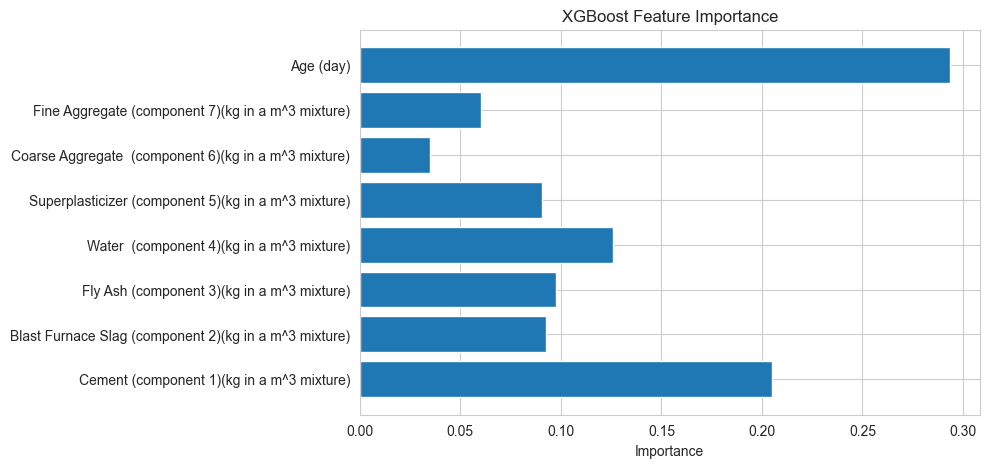

In [55]:
import matplotlib.pyplot as plt

importance = xgb.feature_importances_
features = X.columns

plt.barh(features, importance)
plt.xlabel("Importance")
plt.title("XGBoost Feature Importance")
plt.savefig("results/feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()

E:\Projects\venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Arial.
  fig.canvas.draw()
E:\Projects\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


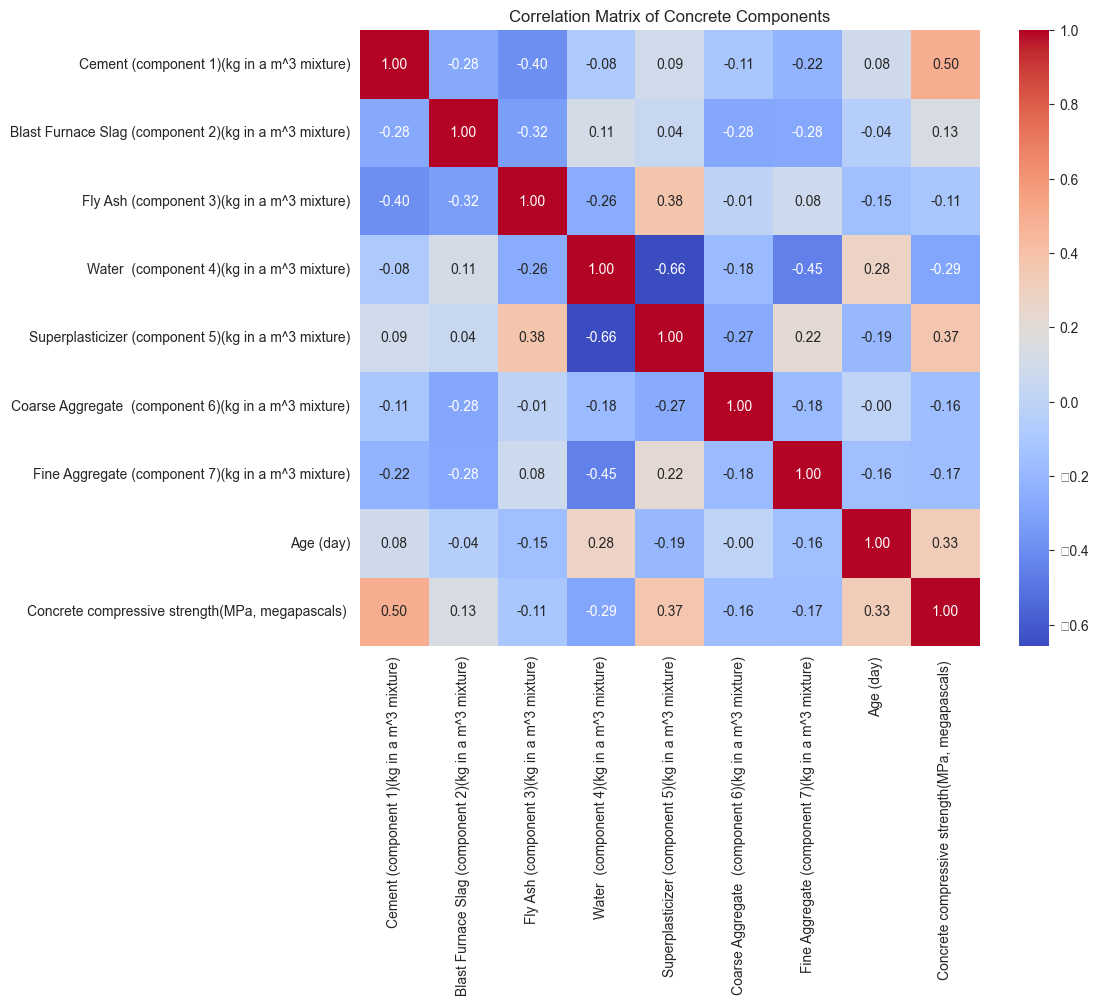

In [44]:
corr = data.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Concrete Components")
plt.show()

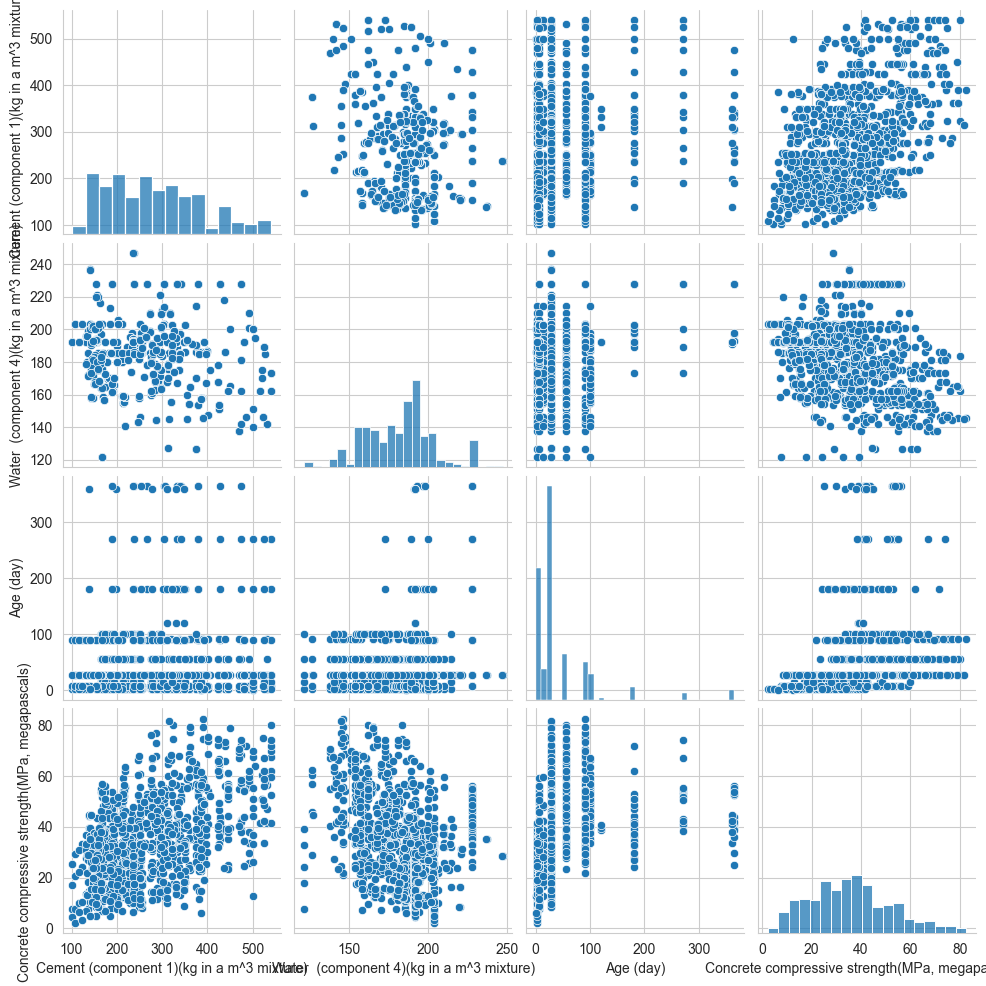

In [56]:
sns.pairplot(data[['Cement (component 1)(kg in a m^3 mixture)',
                   'Water  (component 4)(kg in a m^3 mixture)',
                   'Age (day)',
                   'Concrete compressive strength(MPa, megapascals) ']])
plt.savefig("results/pairplot.png", dpi=300, bbox_inches='tight')
plt.show()

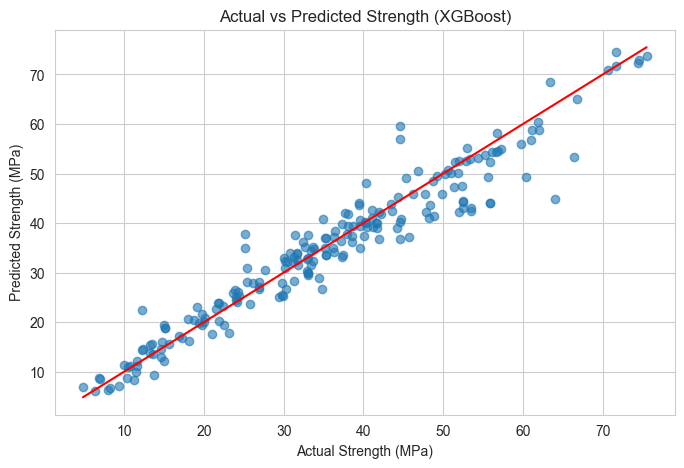

In [47]:
plt.scatter(y_test, y_pred_xgb, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Strength (MPa)")
plt.ylabel("Predicted Strength (MPa)")
plt.title("Actual vs Predicted Strength (XGBoost)")
plt.show()

C:\Users\Shikho\AppData\Local\Temp\ipykernel_1624\1246009812.py:8: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Arial.
  plt.savefig("results/error.png", dpi=300, bbox_inches='tight')
E:\Projects\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


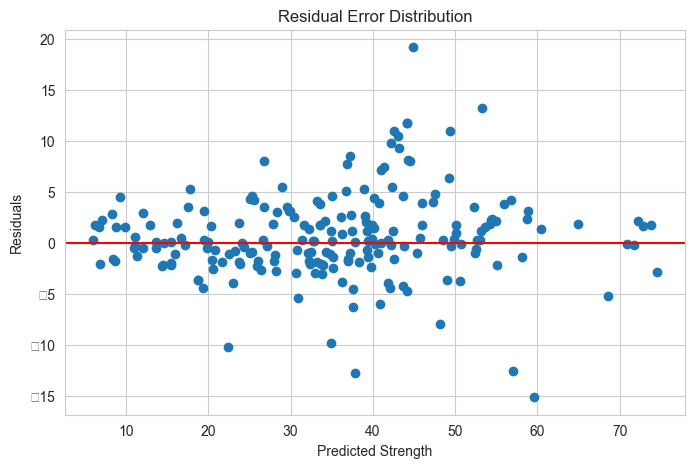

In [57]:
residuals = y_test - y_pred_xgb

plt.scatter(y_pred_xgb, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted Strength")
plt.ylabel("Residuals")
plt.title("Residual Error Distribution")
plt.savefig("results/error.png", dpi=300, bbox_inches='tight')
plt.show()

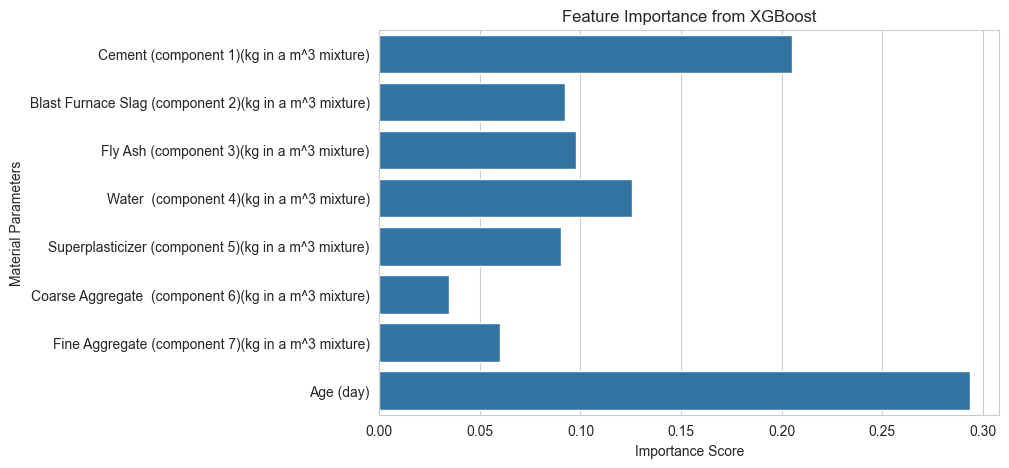

In [58]:
importance = xgb.feature_importances_
features = X.columns

sns.barplot(x=importance, y=features)
plt.title("Feature Importance from XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Material Parameters")
plt.savefig("results/important_feature.png", dpi=300, bbox_inches='tight')
plt.show()

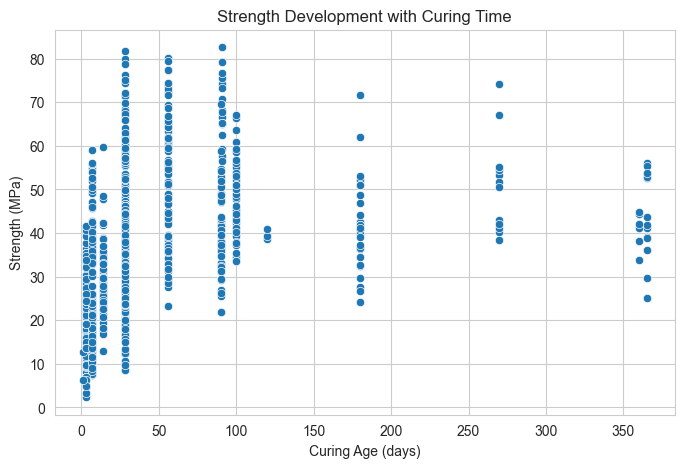

In [59]:
sns.scatterplot(x=data['Age (day)'],
                y=data['Concrete compressive strength(MPa, megapascals) '])

plt.xlabel("Curing Age (days)")
plt.ylabel("Strength (MPa)")
plt.title("Strength Development with Curing Time")
plt.savefig("results/deployment.png", dpi=300, bbox_inches='tight')
plt.show()

In [60]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

results = {}

# Linear Regression
y_lr = model.predict(X_test)
results['Linear Regression'] = (
    r2_score(y_test, y_lr),
    np.sqrt(mean_squared_error(y_test, y_lr))
)

# Random Forest
y_rf = rf.predict(X_test)
results['Random Forest'] = (
    r2_score(y_test, y_rf),
    np.sqrt(mean_squared_error(y_test, y_rf))
)

# Gradient Boosting
y_gbr = gbr.predict(X_test)
results['Gradient Boosting'] = (
    r2_score(y_test, y_gbr),
    np.sqrt(mean_squared_error(y_test, y_gbr))
)

# XGBoost
y_xgb = xgb.predict(X_test)
results['XGBoost'] = (
    r2_score(y_test, y_xgb),
    np.sqrt(mean_squared_error(y_test, y_xgb))
)

results

{'Linear Regression': (0.6275416055429021, np.float64(9.796707832398447)),
 'Random Forest': (0.879131700419671, np.float64(5.580813108491209)),
 'Gradient Boosting': (0.9155291916473146, np.float64(4.66546137144906)),
 'XGBoost': (0.9281757567523556, np.float64(4.3020633597806555))}

In [61]:
import pandas as pd

results_df = pd.DataFrame(results, index=['R2 Score','RMSE']).T
results_df

,R2 Score,RMSE
Linear Regression,0.627542,9.796708
Random Forest,0.879132,5.580813
Gradient Boosting,0.915529,4.665461
XGBoost,0.928176,4.302063


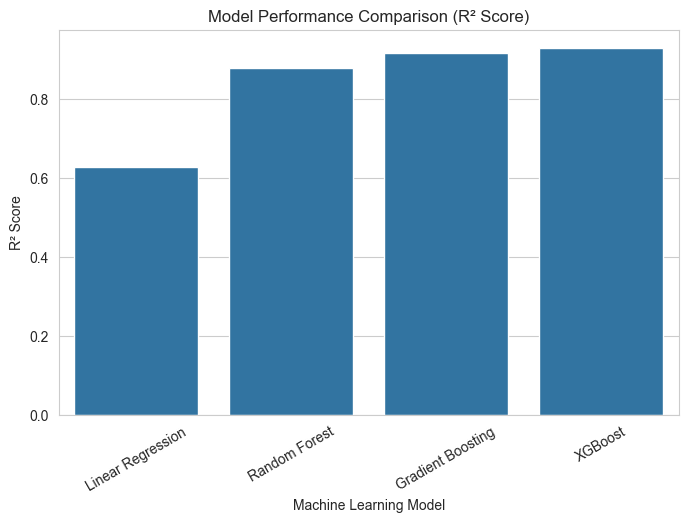

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(x=results_df.index, y=results_df['R2 Score'])

plt.ylabel("R² Score")
plt.xlabel("Machine Learning Model")
plt.title("Model Performance Comparison (R² Score)")
plt.xticks(rotation=30)

plt.savefig("results/model_r2_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

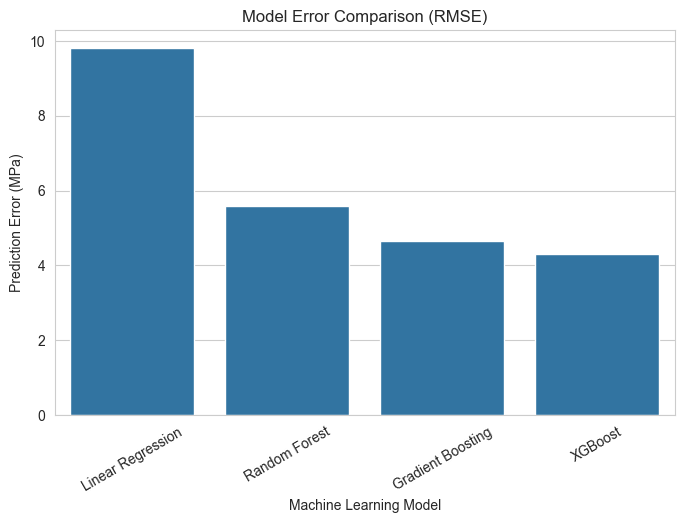

In [63]:
plt.figure(figsize=(8,5))
sns.barplot(x=results_df.index, y=results_df['RMSE'])

plt.ylabel("Prediction Error (MPa)")
plt.xlabel("Machine Learning Model")
plt.title("Model Error Comparison (RMSE)")
plt.xticks(rotation=30)

plt.savefig("results/model_rmse_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Shikho\AppData\Local\Temp\ipykernel_1624\1234754425.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(results_df.index, rotation=30)
C:\Users\Shikho\AppData\Local\Temp\ipykernel_1624\1234754425.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(results_df.index, rotation=30)


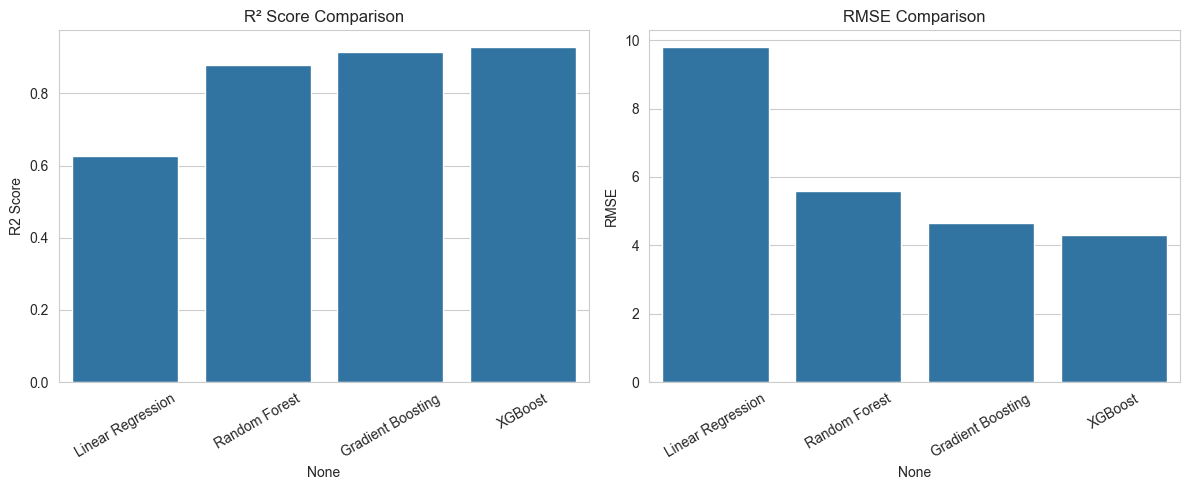

In [64]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.barplot(x=results_df.index, y=results_df['R2 Score'], ax=ax[0])
ax[0].set_title("R² Score Comparison")
ax[0].set_xticklabels(results_df.index, rotation=30)

sns.barplot(x=results_df.index, y=results_df['RMSE'], ax=ax[1])
ax[1].set_title("RMSE Comparison")
ax[1].set_xticklabels(results_df.index, rotation=30)

plt.tight_layout()
plt.savefig("results/model_comparison.png", dpi=300)
plt.show()